# Statevector Benchmark Comparison

This notebook compares correctness and runtime of four methods on the same random circuit:
- einsum simulator (`CustomSimulatorGeneral`)
- mocked Qiskit statevector reference (`mocked_statevector`)
- optimized simulator (python backend)
- optimized simulator (numba backend)

The timing uses `time.perf_counter`, and statevectors are compared up to global phase.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from qiskit import transpile
from qiskit.circuit.random import random_circuit

from fp_qsim.simulator import CustomSimulatorGeneral
from fp_qsim.simulator_optimized import CustomSimulatorManualOptimized
from fp_qsim.state_vector import mocked_statevector

In [2]:
def align_global_phase(reference: np.ndarray, candidate: np.ndarray) -> np.ndarray:
    """Align candidate to reference by matching the phase of the strongest amplitude."""
    anchor = int(np.argmax(np.abs(reference)))
    if np.isclose(candidate[anchor], 0.0):
        return candidate
    return candidate * (reference[anchor] / candidate[anchor])


def make_random_ucx_circuit(n_qubits: int, depth: int, seed: int):
    """Create a random circuit and transpile it to the ['u', 'cx'] basis."""
    qc = random_circuit(n_qubits, depth, measure=False, seed=seed)
    return transpile(qc, basis_gates=["u", "cx"])


def benchmark_method(method_name: str, runner, circuit, repeats: int = 3) -> dict:
    """Time one method over multiple repeats and return runtime stats plus last output."""
    timings = []
    output = None

    for _ in range(repeats):
        start = perf_counter()
        output = runner(circuit)
        end = perf_counter()
        timings.append(end - start)

    return {
        "method": method_name,
        "mean_s": float(np.mean(timings)),
        "min_s": float(np.min(timings)),
        "max_s": float(np.max(timings)),
        "repeats": repeats,
        "statevector": output,
    }


def compare_statevectors(reference: np.ndarray, candidate: np.ndarray, atol: float = 1e-10):
    """Compare candidate with reference up to global phase."""
    aligned = align_global_phase(reference, candidate)
    max_abs_error = float(np.max(np.abs(reference - aligned)))
    return bool(np.allclose(reference, aligned, atol=atol)), max_abs_error

In [3]:
def run_comparison(n_qubits: int = 6, depth: int = 20, seed: int = 42, repeats: int = 3) -> dict:
    """Run correctness and runtime comparison for one random circuit."""
    circuit = make_random_ucx_circuit(n_qubits=n_qubits, depth=depth, seed=seed)

    sim_einsum = CustomSimulatorGeneral()
    sim_opt_python = CustomSimulatorManualOptimized(cx_backend="python")
    sim_opt_numba = CustomSimulatorManualOptimized(cx_backend="numba")

    methods = [
        ("einsum", lambda qc: sim_einsum.run(qc)),
        ("mocked_statevector", lambda qc: mocked_statevector(qc.copy())),
        ("optimized_python", lambda qc: sim_opt_python.run(qc)),
        ("optimized_numba", lambda qc: sim_opt_numba.run(qc)),
    ]

    results = {}
    for method_name, runner in methods:
        results[method_name] = benchmark_method(method_name, runner, circuit, repeats=repeats)

    reference = results["mocked_statevector"]["statevector"]
    comparisons = {}

    for method_name, data in results.items():
        is_close, max_abs_error = compare_statevectors(reference, data["statevector"])
        comparisons[method_name] = {
            "matches_reference": is_close,
            "max_abs_error": max_abs_error,
        }

    header = f"\nComparison for n_qubits={n_qubits}, depth={depth}, seed={seed}, repeats={repeats}"
    print(header)
    print("-" * len(header))
    print(f"{'Method':<20} {'Mean [ms]':>12} {'Min [ms]':>12} {'Max [ms]':>12} {'Match ref':>10} {'Max |err|':>14}")

    for method_name in ["einsum", "mocked_statevector", "optimized_python", "optimized_numba"]:
        timing = results[method_name]
        cmp_data = comparisons[method_name]
        print(
            f"{method_name:<20} "
            f"{timing['mean_s'] * 1_000:>12.3f} "
            f"{timing['min_s'] * 1_000:>12.3f} "
            f"{timing['max_s'] * 1_000:>12.3f} "
            f"{str(cmp_data['matches_reference']):>10} "
            f"{cmp_data['max_abs_error']:>14.3e}"
        )

    return {
        "config": {"n_qubits": n_qubits, "depth": depth, "seed": seed, "repeats": repeats},
        "results": results,
        "comparisons": comparisons,
        "circuit": circuit,
    }

In [4]:
# Single benchmark run
single_result = run_comparison(n_qubits=6, depth=20, seed=42, repeats=3)


Comparison for n_qubits=6, depth=20, seed=42, repeats=3
--------------------------------------------------------
Method                  Mean [ms]     Min [ms]     Max [ms]  Match ref      Max |err|
einsum                      3.010        2.922        3.069       True      3.023e-16
mocked_statevector          3.790        3.703        3.928       True      3.469e-18
optimized_python            2.849        2.810        2.897       True      3.056e-16
optimized_numba           720.088        0.617     2158.962       True      4.246e-16


In [5]:
# Small qubit-count sweep
sweep_results = {}
for n in [4,5,6,7,8,9,10,   11,12,13,14,15,16]:
    sweep_results[n] = run_comparison(n_qubits=n, depth=3 * n, seed=42 + n, repeats=2)


Comparison for n_qubits=4, depth=12, seed=46, repeats=2
--------------------------------------------------------
Method                  Mean [ms]     Min [ms]     Max [ms]  Match ref      Max |err|
einsum                      7.781        2.491       13.070       True      2.782e-16
mocked_statevector          8.034        3.062       13.006       True      1.041e-17
optimized_python            0.568        0.568        0.569       True      4.475e-16
optimized_numba             0.281        0.230        0.333       True      4.858e-16

Comparison for n_qubits=5, depth=15, seed=47, repeats=2
--------------------------------------------------------
Method                  Mean [ms]     Min [ms]     Max [ms]  Match ref      Max |err|
einsum                      1.308        1.153        1.462       True      3.546e-16
mocked_statevector          2.569        2.477        2.662       True      3.469e-18
optimized_python            1.492        0.977        2.006       True      3.442e-1

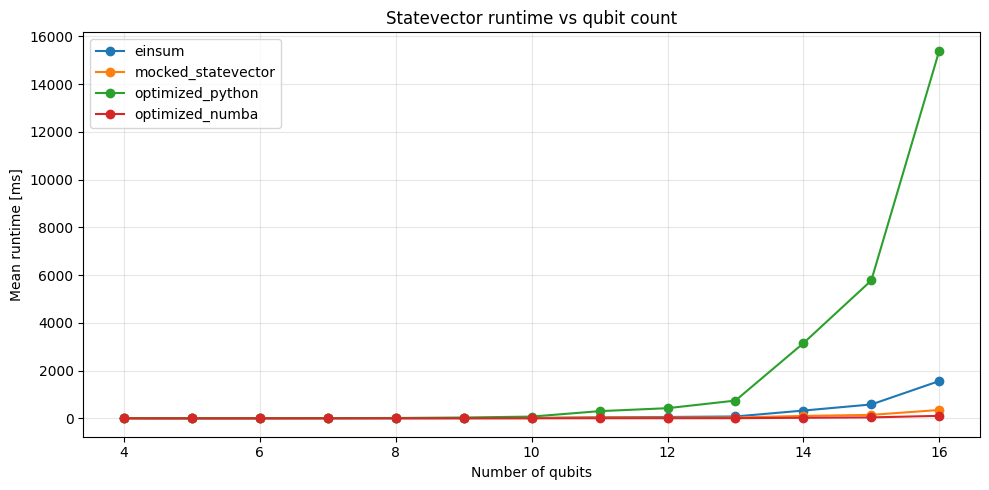

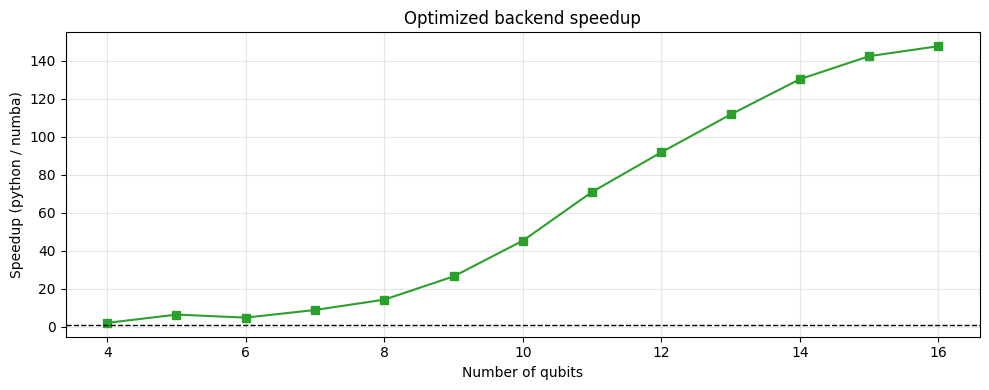

In [6]:
# Plot helper for sweep results
def plot_sweep_results(sweep_results: dict) -> None:
    qubits = sorted(sweep_results.keys())
    methods = ["einsum", "mocked_statevector", "optimized_python", "optimized_numba"]

    # Collect mean runtime in milliseconds for each method
    runtime_ms = {method: [] for method in methods}
    for n in qubits:
        for method in methods:
            runtime_ms[method].append(sweep_results[n]["results"][method]["mean_s"] * 1_000.0)

    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(qubits, runtime_ms[method], marker="o", label=method)
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean runtime [ms]")
    plt.title("Statevector runtime vs qubit count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Speedup of optimized_numba compared to optimized_python
    speedup = [
        runtime_ms["optimized_python"][i] / runtime_ms["optimized_numba"][i]
        for i in range(len(qubits))
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(qubits, speedup, marker="s", color="tab:green")
    plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Number of qubits")
    plt.ylabel("Speedup (python / numba)")
    plt.title("Optimized backend speedup")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_sweep_results(sweep_results)